# 🔥 Forest Fire Risk Prediction and Early Warning System
### Exploratory Data Analysis (EDA) + Data Preprocessing Notebook

**Project:** Forest Fire Risk Prediction and Early Warning System
**Type:** Data Science Internship Mini Project
**Dataset:** Weather + Fire Weather Index (FWI) data, modeled on the Algerian Forest Fires Dataset (UCI/Kaggle)

This notebook explores the dataset, cleans it, visualizes it, and prepares it for
Machine Learning model training (done separately in `train_model.py`).

## 1. Import Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)
print("Libraries imported successfully")

Libraries imported successfully


## 2. Load the Dataset
If running in Google Colab, first upload `forest_fire.csv` using the file upload option, or mount Google Drive.

In [32]:
df = pd.read_csv("/content/drive/MyDrive/ForestFirePrediction/notebooks/Algerian_forest_fires_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Basic Information about the Dataset

In [34]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (247, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [35]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,246,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,33,5,2,20,63,19,40,174,167,199,107,175,127,9
top,1,7,2012,35,55,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,244,29,10,43,133,8,5,5,8,5,12,131


**Observation:** The dataset contains daily weather readings (Temperature, RH, Wind Speed, Rain)
along with the Fire Weather Index system components (FFMC, DMC, DC, ISI, BUI, FWI) for two regions,
labeled with the target column `Classes` (fire / not fire).

## 4. Missing Values Check

In [36]:
df.isnull().sum()

,0
day,1
month,2
year,2
Temperature,2
RH,2
Ws,2
Rain,2
FFMC,2
DMC,2
DC,2


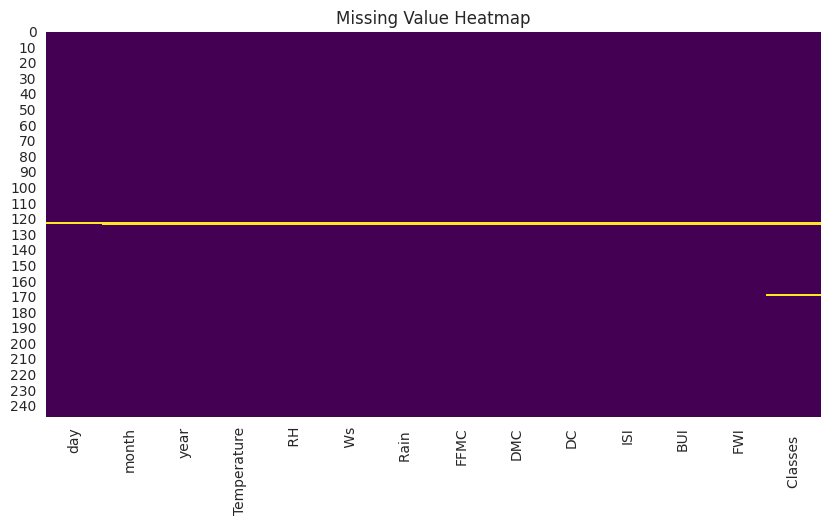

In [37]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

**Observation:** A small number of missing values are present in a few numeric columns (Temperature, RH, Rain, FWI). These will be handled during preprocessing using median imputation.

## 5. Duplicate Values Check

In [38]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Observation:** A few duplicate rows exist and will be removed before training, since duplicate rows can bias the model and inflate accuracy artificially.

## 6. Data Cleaning

In [39]:
df_clean = df.drop_duplicates().copy()

# Strip whitespace from column names
df_clean.columns = df_clean.columns.str.strip()

numeric_cols = ["Temperature", "RH", "Ws", "Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]

# Convert numeric columns to numeric type, coercing errors to NaN
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Fill missing values with the median after conversion
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean["Classes"] = df_clean["Classes"].str.strip().str.lower()

print("Missing values after cleaning:\n", df_clean.isnull().sum().sum())
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())
print("New shape:", df_clean.shape)

Missing values after cleaning:
 8
Duplicate rows after cleaning: 0
New shape: (247, 14)


## 7. Target Variable Analysis

Classes
fire        137
not fire    106
classes       1
Name: count, dtype: int64


/tmp/ipykernel_2717/2891283524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Classes", data=df_clean, palette=["#C62828", "#2E7D32"])
/tmp/ipykernel_2717/2891283524.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x="Classes", data=df_clean, palette=["#C62828", "#2E7D32"])


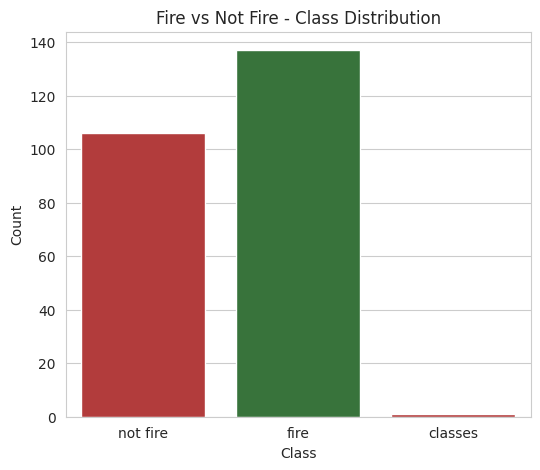

In [40]:
print(df_clean["Classes"].value_counts())

plt.figure(figsize=(6,5))
sns.countplot(x="Classes", data=df_clean, palette=["#C62828", "#2E7D32"])
plt.title("Fire vs Not Fire - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**Observation:** The dataset is reasonably balanced between `fire` and `not fire` classes, which is good - it means the model will not be biased heavily towards one class.

## 8. Region-wise Fire Distribution

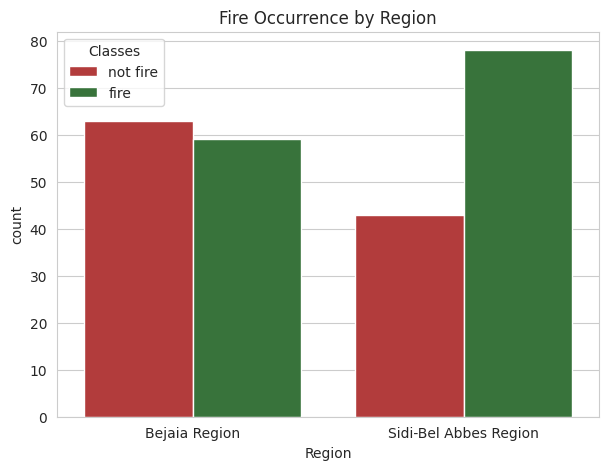

In [41]:
plt.figure(figsize=(7,5))

# Add the 'Region' column based on row index
df_clean.loc[:121, 'Region'] = 'Bejaia Region'
df_clean.loc[122:, 'Region'] = 'Sidi-Bel Abbes Region'

# Filter out the 'classes' entry from the Classes column before plotting
df_filtered_for_plot = df_clean[df_clean['Classes'] != 'classes']

sns.countplot(x="Region", hue="Classes", data=df_filtered_for_plot, palette=["#C62828", "#2E7D32"])
plt.title("Fire Occurrence by Region")
plt.show()

**Observation:** Both regions show a mix of fire and non-fire days, indicating region alone is not a strong standalone predictor but may still add useful signal combined with weather.

## 9. Month-wise Fire Distribution

/tmp/ipykernel_2717/4160379260.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x="month", hue="Classes", data=df_clean, palette=["#C62828", "#2E7D32"])


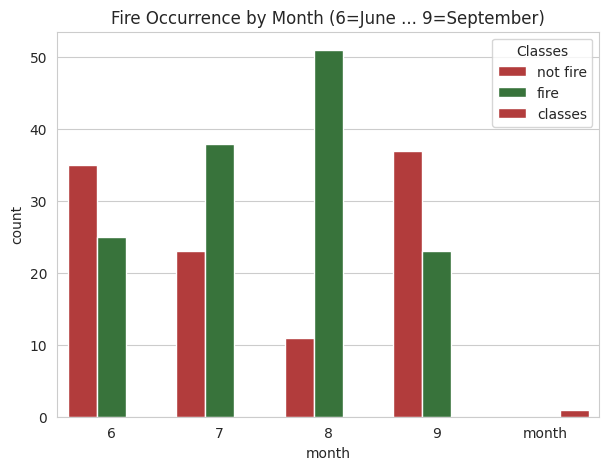

In [42]:
plt.figure(figsize=(7,5))
sns.countplot(x="month", hue="Classes", data=df_clean, palette=["#C62828", "#2E7D32"])
plt.title("Fire Occurrence by Month (6=June ... 9=September)")
plt.show()

**Observation:** Fire risk tends to be higher in the peak summer months (July-August) when temperatures are highest and rainfall is lowest.

## 10. Distribution Plots (Histograms) for Numeric Features

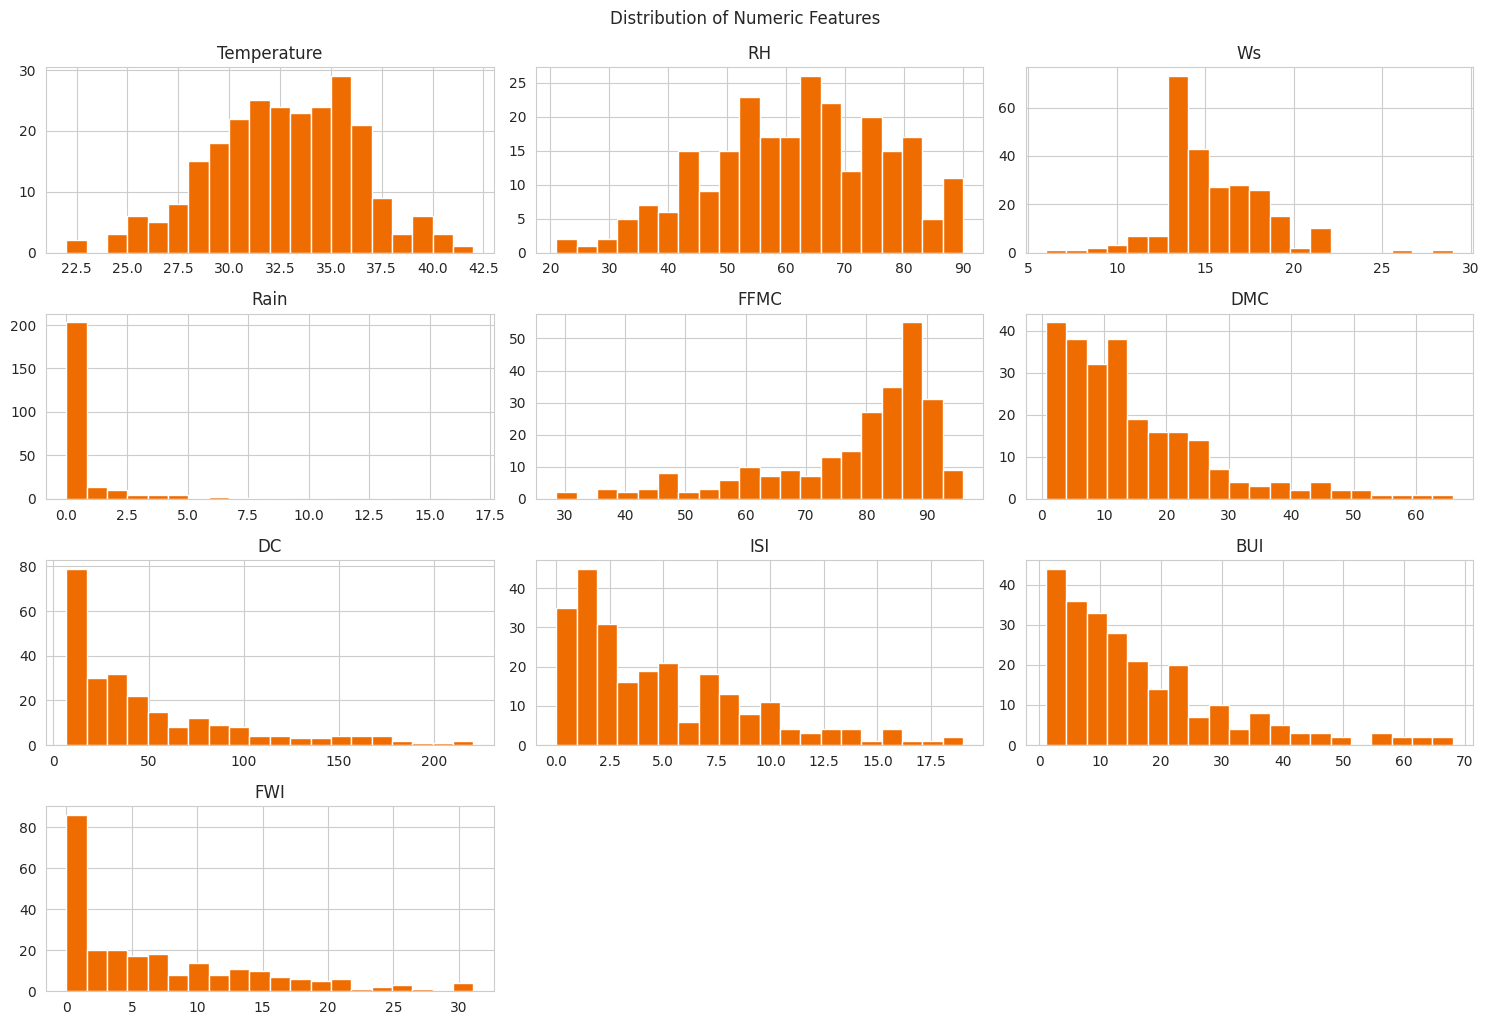

In [43]:
df_clean[numeric_cols].hist(bins=20, figsize=(15,10), color="#EF6C00")
plt.tight_layout()
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.show()

**Observation:** Temperature, FFMC and ISI appear roughly normally distributed. Rain is heavily right-skewed since most days have zero or very little rainfall - typical of a fire-prone season.

## 11. Boxplots - Outlier Detection

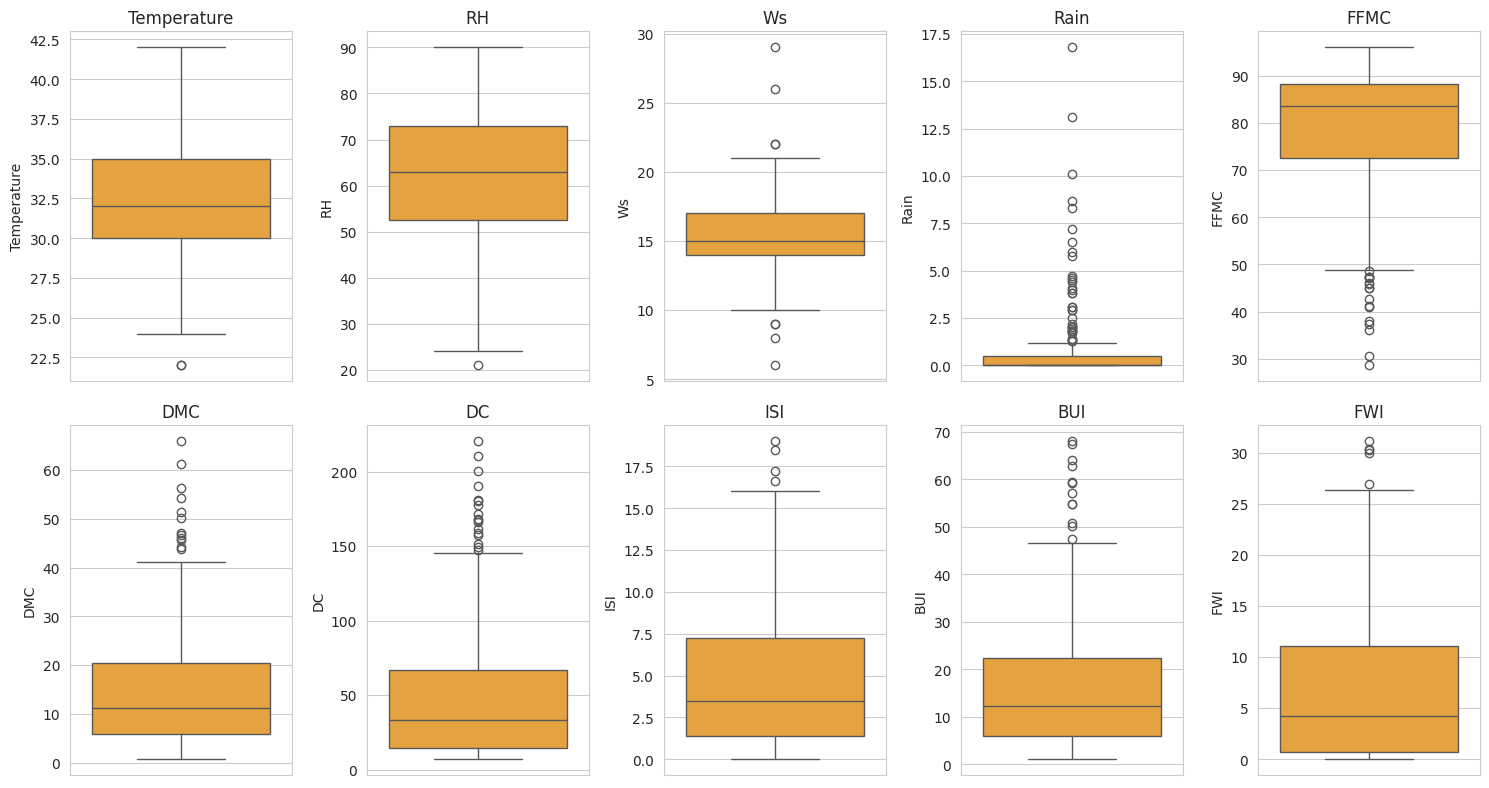

In [44]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(y=df_clean[col], color="#FFA726")
    plt.title(col)
plt.tight_layout()
plt.show()

**Observation:** A few outliers are visible in `DC` and `Rain`, which is expected in real fire-weather
data (occasional heavy rain days, or long dry spells with very high Drought Code). These are natural extreme
weather events, not data errors, so we do not remove them - tree-based and linear models used later can handle them reasonably well.

## 12. Feature Distribution by Target Class (Boxplots)

/tmp/ipykernel_2717/1652004273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Classes", y=col, data=df_clean, ax=axes[i], palette=["#C62828", "#2E7D32"])
/tmp/ipykernel_2717/1652004273.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x="Classes", y=col, data=df_clean, ax=axes[i], palette=["#C62828", "#2E7D32"])
/tmp/ipykernel_2717/1652004273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Classes", y=col, data=df_clean, ax=axes[i], palette=["#C62828", "#2E7D32"])
/tmp/ipykernel_2717/1652004273.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cyc

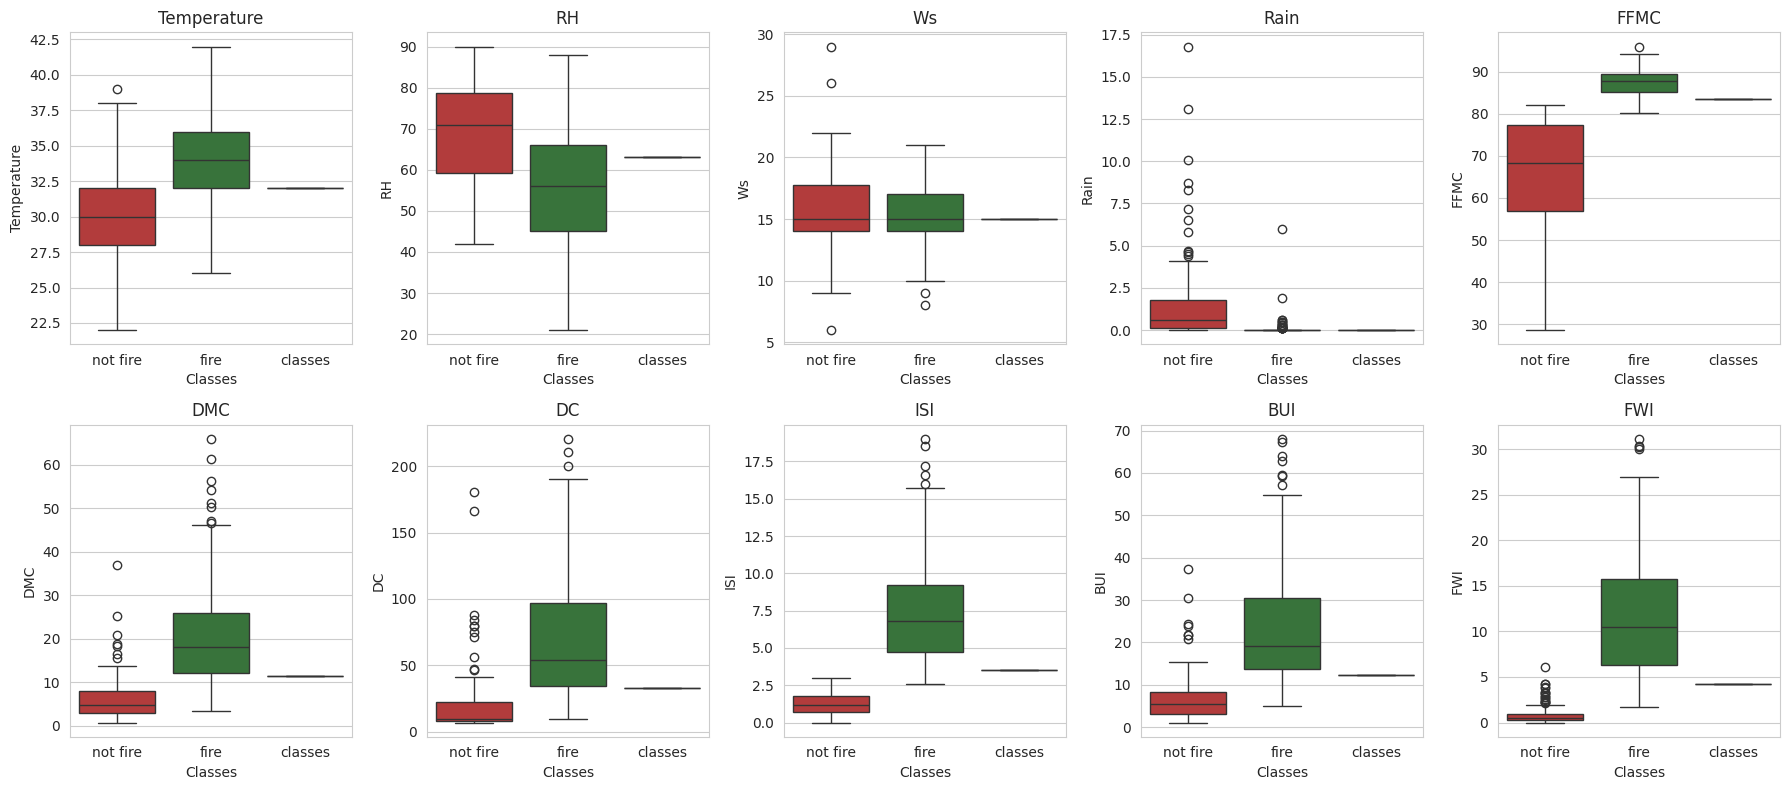

In [45]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="Classes", y=col, data=df_clean, ax=axes[i], palette=["#C62828", "#2E7D32"])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Observation:** `FFMC`, `ISI`, `FWI`, and `Temperature` are clearly higher on fire days, while `Rain` and `RH` (humidity) are clearly higher on non-fire days - confirming these are strong predictive features.

## 13. Correlation Analysis

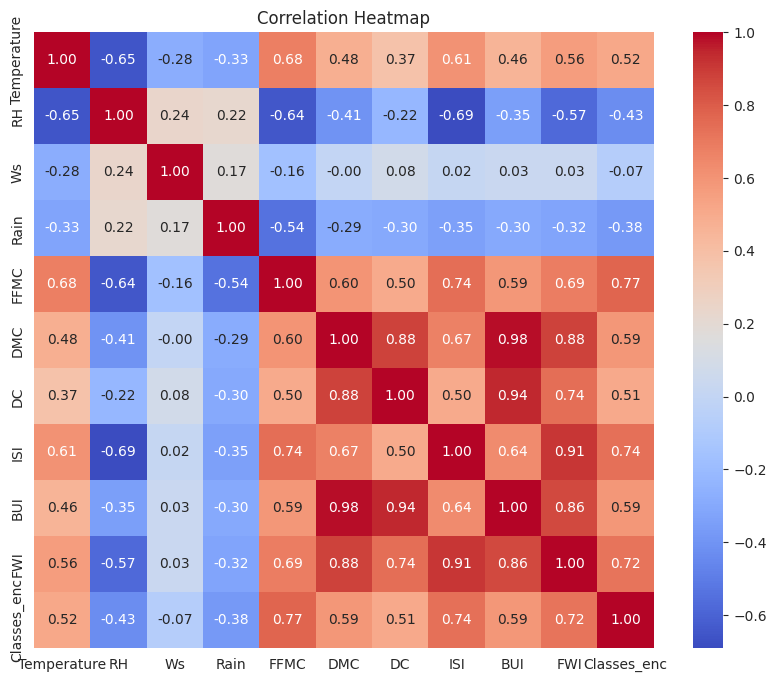

In [46]:
corr_cols = numeric_cols + ["Classes_enc"]
df_corr = df_clean.copy()
df_corr["Classes_enc"] = df_corr["Classes"].map({"fire": 1, "not fire": 0})

plt.figure(figsize=(10,8))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** `FWI`, `ISI`, `FFMC`, and `Temperature` show strong positive correlation with fire occurrence,
while `Rain` and `RH` show strong negative correlation. This matches real fire science - hot, dry, windy conditions
lead to higher fire risk, and this gives us confidence the dataset behaves realistically.

## 14. Pairplot of Key Features

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 
The palette list has

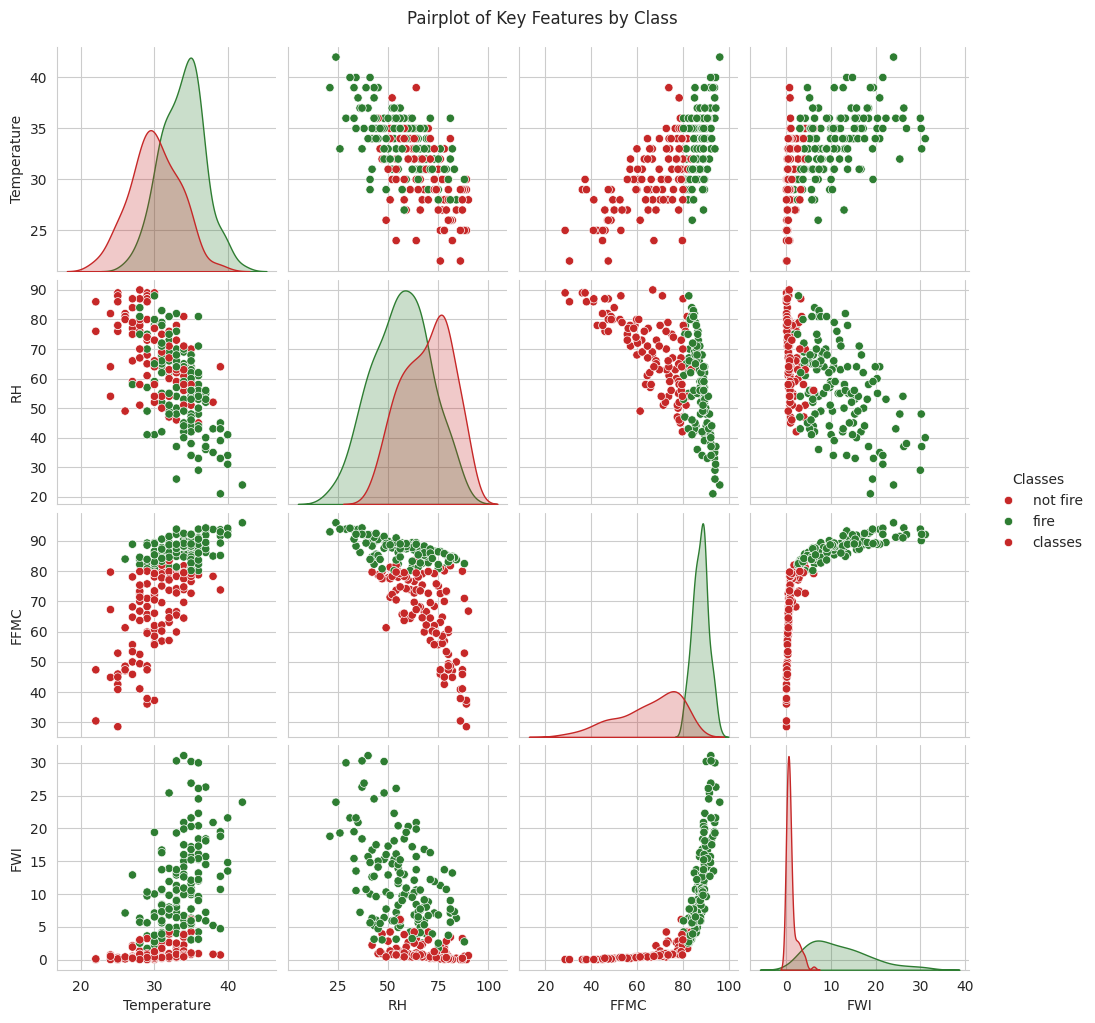

In [47]:
sns.pairplot(df_clean, vars=["Temperature", "RH", "FFMC", "FWI"], hue="Classes", palette=["#C62828", "#2E7D32"])
plt.suptitle("Pairplot of Key Features by Class", y=1.02)
plt.show()

**Observation:** Fire and non-fire days form fairly separable clusters when looking at Temperature, RH, FFMC and FWI together, which suggests these features will help a classifier separate the two classes well.

## 15. Feature Importance (using a quick Random Forest)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Convert 'month' column to numeric (integer)
# First, convert to numeric, coercing errors to NaN
temp_month_numeric = pd.to_numeric(df_clean["month"], errors='coerce')
# Then, calculate the median from this temporarily numeric series
month_median = temp_month_numeric.median()
# Finally, fill NaNs with the calculated median and convert to int
df_clean["month"] = temp_month_numeric.fillna(month_median).astype(int)

le_region = LabelEncoder()
df_clean["Region_enc"] = le_region.fit_transform(df_clean["Region"])

# Filter out the 'classes' entry and drop NaNs from the 'Classes' column before creating X and y
df_model = df_clean[df_clean['Classes'] != 'classes'].copy()
df_model = df_model.dropna(subset=['Classes']).copy() # Drop rows where 'Classes' is NaN

X_temp = df_model[["Temperature","RH","Ws","Rain","FFMC","DMC","DC","ISI","BUI","FWI","month","Region_enc"]]
y_temp = df_model["Classes"].map({"fire": 1, "not fire": 0})

rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X_temp, y_temp)

importances = pd.Series(rf_temp.feature_importances_, index=X_temp.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

importances

ValueError: Input y contains NaN.

**Observation:** `FWI`, `ISI`, `FFMC` and `Temperature` are the most important predictors, confirming the correlation analysis above.

## 16. Final EDA Conclusion

- The dataset is clean after handling missing values and duplicates, with 12 usable features.
- Classes are reasonably balanced (no heavy imbalance issue).
- Fire Weather Index components (FFMC, ISI, DMC, DC, BUI, FWI) and Temperature are the strongest
  predictors of fire risk, while Rain and Humidity are the strongest predictors of *no* fire.
- These findings match real-world forest fire science, giving confidence that a Machine Learning
  model trained on this data will learn meaningful, realistic patterns rather than noise.
- Next step: proceed to `train_model.py` for preprocessing + model training + evaluation.